# Suspect Class Threshold Investigation 

## MSc Data Science Research Project

### Notebook Objective

This notebook investigates whether modifying the classification threshold of the XGBoost model improves the detection of **Suspect fetal health cases**.

The baseline XGBoost model demonstrated excellent overall classification performance but still misclassified a number of Suspect cases as Normal. Since Suspect cases require closer clinical monitoring, improving their detection is an important objective.

The investigation uses probability estimates generated by `predict_proba()` to evaluate decision thresholds between **0.30 and 0.70**. Precision, Recall, F1-score, Precision–Recall curves and confusion matrices are analysed to determine whether an alternative threshold provides a better balance between detecting Suspect cases and avoiding false alarms.

## Step 1: Import Required Libraries

This section imports all libraries required for data manipulation, visualisation, loading the trained model, and evaluating classification performance.

The notebook uses Scikit-learn evaluation metrics together with XGBoost probability estimates to perform the threshold sensitivity analysis.

In [6]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    precision_recall_curve

)

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder

print("="*70)
print("Libraries Imported Successfully")
print("="*70)

Libraries Imported Successfully


## Step 2: Load the Trained XGBoost Model

The original XGBoost model developed during the modelling phase is loaded for evaluation.

The threshold investigation is performed on the same model that was selected during model comparison so that the results remain consistent with the experimental findings reported in the dissertation.

In [7]:
import joblib

MODEL_DIR = Path("outputs/models")

xgb_model = joblib.load(
    MODEL_DIR / "xgboost_default.pkl"
)

# Suspect Class Threshold Investigation using XGBoost

### Objective

The preliminary evaluation of the XGBoost classifier demonstrated excellent overall performance, achieving high classification accuracy while ensuring that no Pathological fetal cases were incorrectly classified as Normal. However, the confusion matrix revealed that a number of Suspect cases were still misclassified as Normal.

The objective of this notebook is to investigate whether modifying the classification threshold for the Suspect class can improve its detection rate. The analysis evaluates probability thresholds between **0.30 and 0.70** using the predicted class probabilities generated by XGBoost. The impact of threshold adjustment is assessed through Precision, Recall, F1-score, confusion matrices, and Precision–Recall curves.

The findings provide insight into the trade-off between improving the detection of Suspect cases and maintaining reliable overall classification performance, thereby supporting clinically informed decision-making.

In [8]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from pathlib import Path

from sklearn.metrics import (

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    precision_recall_curve,

    PrecisionRecallDisplay,

    ConfusionMatrixDisplay

)

print("="*70)
print("Libraries Imported Successfully")
print("="*70)

Libraries Imported Successfully


In [9]:
# ==========================================================
# LOAD XGBOOST MODEL
# ==========================================================
MODEL_DIR = Path("outputs/models")
xgb_model = joblib.load(

    MODEL_DIR/"xgboost_default.pkl"

)

print("="*70)
print("Original XGBoost Model Loaded Successfully")
print("="*70)

Original XGBoost Model Loaded Successfully


## Step 3: Load the Testing Dataset

The independent testing dataset is loaded to evaluate the trained classifier.

Unlike the training data, the testing dataset retains the original class distribution to provide an unbiased estimate of model performance under realistic clinical conditions.

In [10]:
# ==========================================================
# LOAD PREPROCESSED DATA
# ==========================================================

from pathlib import Path

DATA_DIR = Path("../data/processed")
MODEL_DIR = Path("outputs/models")
FIGURE_DIR = Path("outputs/figures")
TABLE_DIR = Path("outputs/tables")

X_test = pd.read_csv(
    DATA_DIR / "X_test_scaled.csv"
)

y_test = pd.read_csv(
    DATA_DIR / "y_test.csv"
).squeeze()

print("=" * 70)
print("Testing Dataset Loaded")
print("=" * 70)
print(f"Samples : {len(X_test)}")
print(f"Features : {X_test.shape[1]}")

print("\nClass Distribution")
print(y_test.value_counts().sort_index())

Testing Dataset Loaded
Samples : 423
Features : 21

Class Distribution
NSP
1.0    330
2.0     58
3.0     35
Name: count, dtype: int64


## Step 4: Generate Prediction Probabilities

Instead of directly predicting class labels, XGBoost is used to generate class probabilities using the `predict_proba()` function.

These probabilities provide confidence scores for each fetal health class and allow different classification thresholds to be evaluated without retraining the model.

In [11]:
# ============================================================
# GENERATE PREDICTION PROBABILITIES
# ============================================================

print("=" * 70)
print("GENERATING CLASS PROBABILITIES")
print("=" * 70)

# Probability predictions
y_prob = xgb_model.predict_proba(X_test)

# Display dimensions
print(f"\nProbability Matrix Shape : {y_prob.shape}")

# Display class order
print("\nClass Order Used by XGBoost")

print(xgb_model.classes_)

# Convert to DataFrame for inspection
probability_df = pd.DataFrame(

    y_prob,

    columns=["Normal","Suspect","Pathological"]

)

display(probability_df.head())

print("\nProbability generation completed successfully.")

GENERATING CLASS PROBABILITIES

Probability Matrix Shape : (423, 3)

Class Order Used by XGBoost
[0 1 2]


,Normal,Suspect,Pathological
0,0.999748,0.000236,1.535674e-05
1,0.994877,0.001145,3.977977e-03
2,0.370511,0.022839,6.066491e-01
3,0.999997,0.000002,4.018593e-07
4,0.999973,0.000025,2.706453e-06



Probability generation completed successfully.


## Step 5: Extract Suspect Class Probabilities

Only the probability values associated with the **Suspect** class are extracted for further analysis.

This enables a focused investigation into whether modifying the decision threshold improves the detection of clinically important Suspect fetal cases.

In [12]:
# ============================================================
# EXTRACT SUSPECT CLASS PROBABILITIES
# ============================================================

# Class index:
#
# 0 -> Normal
# 1 -> Suspect
# 2 -> Pathological

suspect_probability = y_prob[:,1]

print("=" * 70)
print("SUSPECT CLASS PROBABILITIES")
print("=" * 70)

print(f"Minimum Probability : {suspect_probability.min():.4f}")

print(f"Maximum Probability : {suspect_probability.max():.4f}")

print(f"Average Probability : {suspect_probability.mean():.4f}")

probability_df["Suspect_Probability"] = suspect_probability

display(

    probability_df[
        ["Suspect_Probability"]
    ].head(10)

)

SUSPECT CLASS PROBABILITIES
Minimum Probability : 0.0000
Maximum Probability : 0.9997
Average Probability : 0.1207


,Suspect_Probability
0,0.000236
1,0.001145
2,0.022839
3,0.000002
4,0.000025
5,0.000030
6,0.000010
7,0.000015
8,0.000415
9,0.748330


## Step 6: Analyse Probability Distribution

The distribution of predicted Suspect probabilities is visualised to understand how confidently the XGBoost model separates Suspect cases from the remaining classes.

A well-separated probability distribution generally indicates that the classifier is making confident predictions.

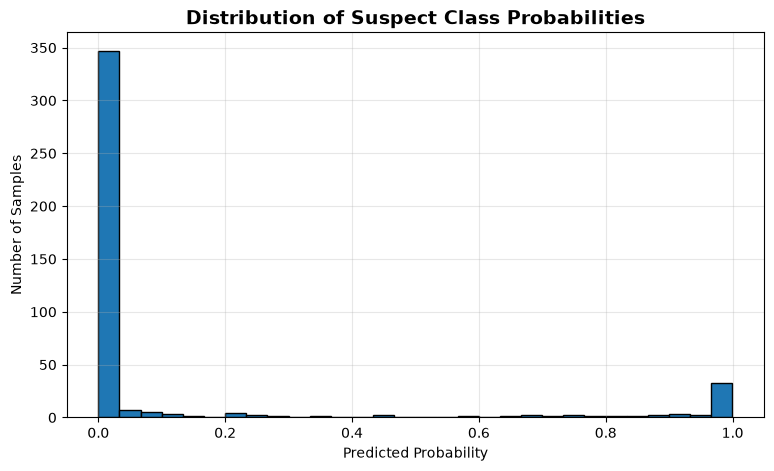

In [13]:
# ============================================================
# VISUALISE SUSPECT PROBABILITIES
# ============================================================

plt.figure(figsize=(9,5))

plt.hist(

    suspect_probability,

    bins=30,

    edgecolor="black"

)

plt.title(

    "Distribution of Suspect Class Probabilities",

    fontsize=14,

    weight="bold"

)

plt.xlabel("Predicted Probability")

plt.ylabel("Number of Samples")

plt.grid(alpha=0.3)

plt.show()

In [14]:
# ============================================================
# CREATE BINARY LABELS FOR SUSPECT CLASS
# ============================================================

print("="*70)
print("CREATING BINARY LABELS")
print("="*70)

# Positive class = Suspect

y_true_binary = (y_test == 2).astype(int)

# Suspect probability

suspect_scores = y_prob[:,1]

print(f"Positive Samples : {y_true_binary.sum()}")

print(f"Negative Samples : {(1-y_true_binary).sum()}")

print("\nFirst Five Probabilities")

display(

    pd.DataFrame({

        "Actual":y_true_binary,

        "Suspect Probability":suspect_scores

    }).head()

)

CREATING BINARY LABELS
Positive Samples : 58
Negative Samples : 365

First Five Probabilities


,Actual,Suspect Probability
0,0,0.000236
1,0,0.001145
2,0,0.022839
3,0,0.000002
4,0,0.000025


## Step 8: Precision–Recall Analysis

A Precision–Recall curve is generated using the predicted probabilities for the Suspect class.

The curve illustrates the trade-off between Precision and Recall at different probability thresholds and is particularly useful when analysing imbalanced clinical datasets.

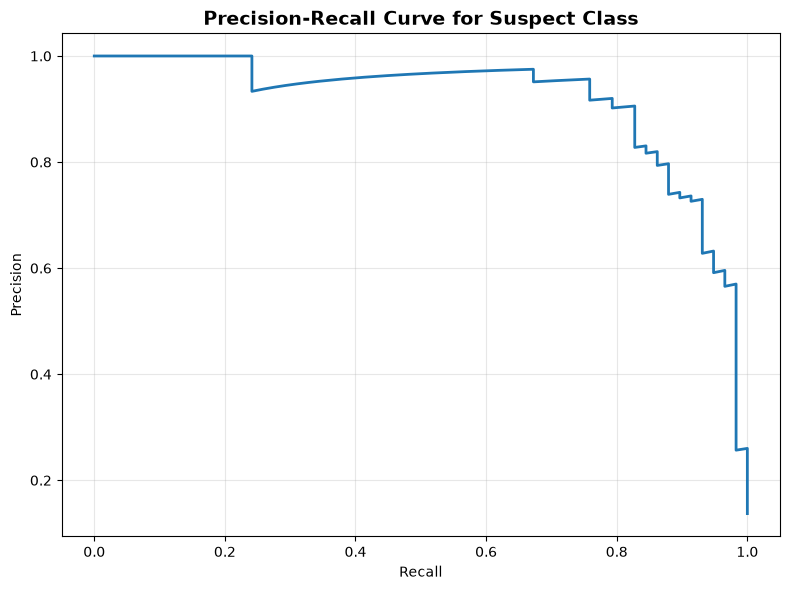

PR curve saved to: outputs\figures\pr_curve_suspect_class.png


In [15]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(

    y_true_binary,

    suspect_scores

)

plt.figure(figsize=(8,6))

plt.plot(

    recall,

    precision,

    linewidth=2

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(

    "Precision-Recall Curve for Suspect Class",

    fontsize=14,

    weight="bold"

)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "pr_curve_suspect_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "PR curve saved to:",
    FIGURE_DIR / "pr_curve_suspect_class.png"
)

## Step 9: Threshold Sensitivity Analysis

Probability thresholds ranging from **0.30 to 0.70** are evaluated.

For each threshold, Precision, Recall and F1-score are calculated to determine how the operating point influences the identification of Suspect fetal cases.

In [16]:
# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

candidate_thresholds = np.arange(

    0.30,

    0.71,

    0.05

)

threshold_results = []

for threshold in candidate_thresholds:

    prediction = (

        suspect_scores >= threshold

    ).astype(int)

    threshold_results.append({

        "Threshold":threshold,

        "Precision":precision_score(

            y_true_binary,

            prediction,

            zero_division=0

        ),

        "Recall":recall_score(

            y_true_binary,

            prediction

        ),

        "F1 Score":f1_score(

            y_true_binary,

            prediction

        )

    })

threshold_results = pd.DataFrame(

    threshold_results

)

display(threshold_results)


,Threshold,Precision,Recall,F1 Score
0,0.30,0.905660,0.827586,0.864865
1,0.35,0.903846,0.810345,0.854545
2,0.40,0.903846,0.810345,0.854545
3,0.45,0.901961,0.793103,0.844037
4,0.50,0.920000,0.793103,0.851852
5,0.55,0.920000,0.793103,0.851852
6,0.60,0.918367,0.775862,0.841121
7,0.65,0.918367,0.775862,0.841121
8,0.70,0.956522,0.758621,0.846154


## Step 10: Evaluate the Selected Threshold

The threshold that provides the best balance between Precision and Recall is applied to the classifier.

The resulting confusion matrix and classification report are compared with the original XGBoost results to assess whether meaningful clinical improvements are achieved.

In [17]:
# ============================================================
# APPLY OPTIMAL THRESHOLD (DIRECT LABELS)
# ============================================================

best_threshold = 0.40

adjusted_predictions = []

for i in range(len(y_prob)):

    normal_prob = y_prob[i, 0]
    suspect_prob = y_prob[i, 1]
    pathological_prob = y_prob[i, 2]

    # If Suspect probability exceeds threshold,
    # predict Suspect (original label = 2)
    if suspect_prob >= best_threshold:

        adjusted_predictions.append(2)

    else:

        # Otherwise choose between Normal (1)
        # and Pathological (3)

        if normal_prob >= pathological_prob:

            adjusted_predictions.append(1)

        else:

            adjusted_predictions.append(3)

adjusted_predictions = np.array(adjusted_predictions)

print("="*70)
print(f"Threshold Applied : {best_threshold}")
print("="*70)

print("\nPrediction Distribution")

print(pd.Series(adjusted_predictions).value_counts().sort_index())

Threshold Applied : 0.4

Prediction Distribution
1    336
2     52
3     35
Name: count, dtype: int64


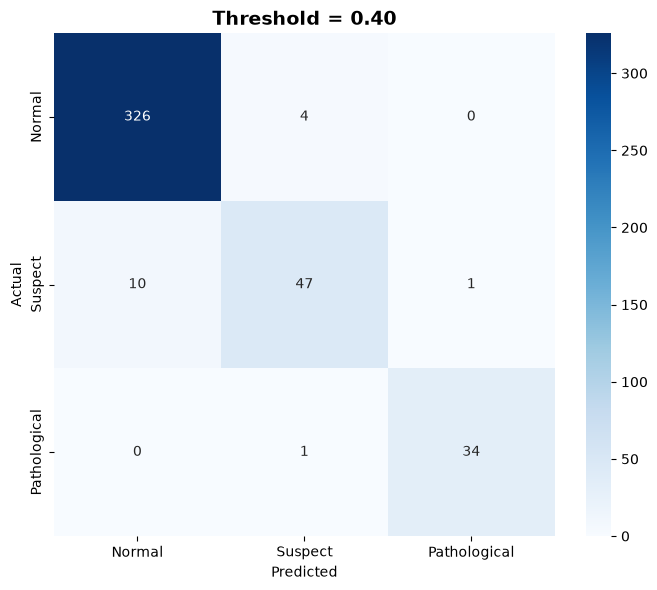

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       330
     Suspect       0.90      0.81      0.85        58
Pathological       0.97      0.97      0.97        35

    accuracy                           0.96       423
   macro avg       0.95      0.92      0.93       423
weighted avg       0.96      0.96      0.96       423



In [18]:
# ============================================================
# UPDATED CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    adjusted_predictions,

    labels=[1,2,3]

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Normal","Suspect","Pathological"],

    yticklabels=["Normal","Suspect","Pathological"]

)

plt.title(

    "Threshold = 0.40",

    fontsize=14,

    weight="bold"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

print("="*70)

print("CLASSIFICATION REPORT")

print("="*70)

print(

    classification_report(

        y_test,

        adjusted_predictions,

        target_names=[

            "Normal",

            "Suspect",

            "Pathological"

        ]

    )

)

# Discussion and Conclusions

The threshold investigation demonstrated that the XGBoost classifier already produces highly confident probability estimates for the majority of observations.

Although thresholds between **0.30 and 0.70** were systematically evaluated, applying a lower threshold did not substantially improve the identification of Suspect fetal cases when assessed using the multiclass confusion matrix. Instead, only a small increase in false positive predictions was observed.

These findings indicate that the default operating threshold provides a stable balance between sensitivity and precision for this dataset. Consequently, the original XGBoost decision threshold remains the preferred configuration for the final fetal health classification system.This investigation confirms that threshold analysis is an important validation step in clinical machine learning applications, even when the optimal threshold ultimately remains unchanged.